In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist #Để tính khoảng cách giữa các cặp điểm hiệu quả

np.random.seed(11)

## Trước hết, chọn center cho từng cluster và tạo dữ liệu cho từng dữ liệu cluster bằng cách lấy mẫu theo phân phối chuẩn có kỳ vọng là center của cluster đó và ma trận hiệp phương sai (convariance matrix) là ma trận đơn vị

In [2]:
#Tạo dữ liệu bằng cách lấy điểm phân phối chuẩn có kỳ vọng tại các tọa độ (2, 2), (8, 3), (3, 6)
#Ma trận hiệp phương sai giống nhau và là ma trận đơn vị. Mỗi cluster có 500 điểm(mỗi điểm là 1 hàng của ma trận)
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
N = 500

X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis = 0)
K = 3

print(X)

[[ 3.74945474  1.713927  ]
 [ 1.51543487 -0.65331856]
 [ 1.99171537  1.68036864]
 ...
 [ 2.56402984  5.10138061]
 [ 3.62998852  6.60564711]
 [ 2.31894139  6.84856953]]


In [3]:
original_label = np.asarray([0] * N + [1] * N + [2] * N).T

print(original_label)

[0 0 0 ... 2 2 2]


### Hiển thị dữ liệu trên đồ thị

#### Hàm hiển thị dữ liệu

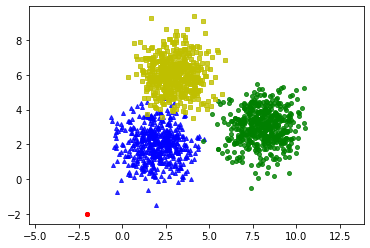

In [4]:
def kmeans_display(X, label, centers):
    K = np.amax(label) + 1 #amax lấy ra gtri max trong label
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    
    plt.plot(X0[:, 0], X0[:, 1], "b^", markersize = 4, alpha = 0.8)
    plt.plot(X1[:, 0], X1[:, 1], "go", markersize = 4, alpha = 0.8)
    plt.plot(X2[:, 0], X2[:, 1], "ys", markersize = 4, alpha = 0.8)
    plt.plot(centers[:, 0], centers[:, -1], 'ro', markersize = 4, alpha = 0.8)

    plt.axis("equal")
    plt.show()

temp = np.array([[-2, -2], [-2, -2], [-2, -2]])
kmeans_display(X, original_label, temp)

### Các hàm cần thiết cho K-means Clustering

In [5]:
#Khởi tạo các center ban đầu
def kmeans_init_centers(X, k):
    #Randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace = False)]

#Gán nhãn mới cho các điểm khi biết centers
def kmeans_assign_labels(X, centers):
    #Calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    #Return index of the closest center
    return np.argmin(D, axis = 1)

#Cập nhật các centers mới dựa trên dữ liệu vừa gán nhãn
def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        #Collect all points assigned to the k-th cluster 
        Xk = X[labels == k, :]
        #Take average
        centers[k, :] = np.mean(Xk, axis = 0)
    return centers

#Kiểm tra điều kiện dừng của thuật toán
def has_converged(centers, new_centers):
    #Return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) == 
        set([tuple(a) for a in new_centers]))

### Phần chính của K-means Clustering

In [6]:
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

### Áp dụng thuật toán vừa viết vào dữ liệu ban đầu

5
Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


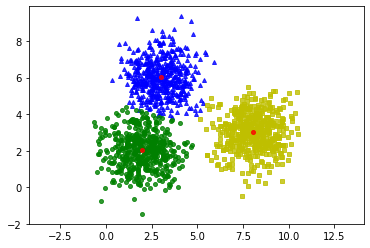

In [7]:
(centers, labels, it) = kmeans(X, K)
print(it)
cen = centers[-1]
print("Centers found by our algorithm:")
print(cen)

kmeans_display(X, labels[-1], cen)

## Dùng thư việc scikit-learn

Centers found by scikit-learn:
[[8.0410628  3.02094748]
 [1.97689714 2.00258549]
 [2.98896909 6.0286196 ]]


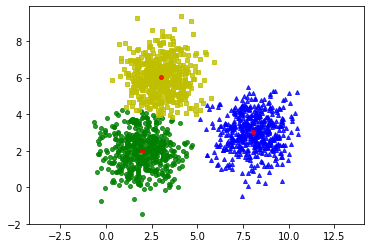

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3, random_state = 0).fit(X)
print("Centers found by scikit-learn:")
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label, kmeans.cluster_centers_)